# GRU의 기억 구조와 RNN·LSTM 비교

GRU(Gated Recurrent Unit)는 기본 RNN의 장기 의존성 문제를 완화하기 위해 **업데이트 게이트와 리셋 게이트**를 사용하는 순환 신경망이다. LSTM과 목적은 비슷하지만 별도의 셀 상태 없이 은닉 상태 하나로 기억과 출력을 관리한다.

이 노트북에서는 GRU 자체의 기억 갱신 과정을 먼저 이해한다. 그다음 같은 입력을 RNN·LSTM·GRU에 전달하여 반환값, 파라미터 수와 문장 벡터가 어떻게 달라지는지 비교하고, 실제 텍스트 분류에서 토큰 ID가 GRU 로짓으로 변환되는 흐름을 확인한다.

## 01. GRU가 필요한 이유

기본 RNN은 현재 입력과 이전 은닉 상태를 이용해 새로운 은닉 상태를 만든다. 이 상태 하나를 매 토큰마다 반복해서 갱신하므로 긴 시퀀스에서는 앞부분의 중요한 정보가 약해지고, 역전파 과정에서 기울기가 매우 작아질 수 있다.

LSTM은 셀 상태와 세 게이트를 추가해 정보가 오래 전달될 경로를 만든다. GRU는 같은 문제를 더 단순한 구조로 다루기 위해 **셀 상태와 은닉 상태를 하나의 은닉 상태로 합치고**, 게이트도 업데이트·리셋 두 종류만 사용한다.

구조가 단순하다는 것은 일반적으로 같은 입력·은닉 크기에서 파라미터와 계산량이 줄어든다는 뜻이다. GRU가 LSTM보다 항상 빠르거나 정확하다는 뜻은 아니므로 실제 데이터의 validation 성능과 실행 시간을 함께 비교해야 한다.

```text
기본 RNN: 은닉 상태 1개 + 별도 게이트 없음
LSTM    : 셀 상태 1개 + 은닉 상태 1개 + 게이트 3개
GRU     : 은닉 상태 1개 + 게이트 2개
```

## 02. 업데이트 게이트와 리셋 게이트

GRU는 이전 은닉 상태 $h_{t-1}$와 현재 입력 $x_t$를 사용해 현재 은닉 상태 $h_t$를 만든다. 이 은닉 상태 하나가 현재 위치의 출력이면서 다음 토큰으로 전달할 기억이다.

- **리셋 게이트 $r_t$**: 새 후보 상태를 만들 때 이전 기억을 얼마나 참고할지 조절
- **업데이트 게이트 $z_t$**: 이전 상태와 새 후보 상태를 어떤 비율로 섞을지 조절
- **후보 은닉 상태 $n_t$**: 현재 입력과 리셋 게이트가 조절한 이전 정보를 이용해 만든 새로운 기억 후보

리셋 게이트는 최종 은닉 상태를 직접 삭제하는 스위치가 아니다. 후보 상태를 계산하는 경로에서 과거 정보의 영향만 조절한다. 업데이트 게이트는 이전 상태와 후보 상태를 혼합하여 최종 $h_t$를 만든다.

두 게이트 값은 사람이 미리 지정하지 않는다. 감성 레이블과 손실을 이용한 학습 과정에서 어떤 정보를 유지하거나 새로 반영해야 오차가 줄어드는지 가중치가 조정된다.

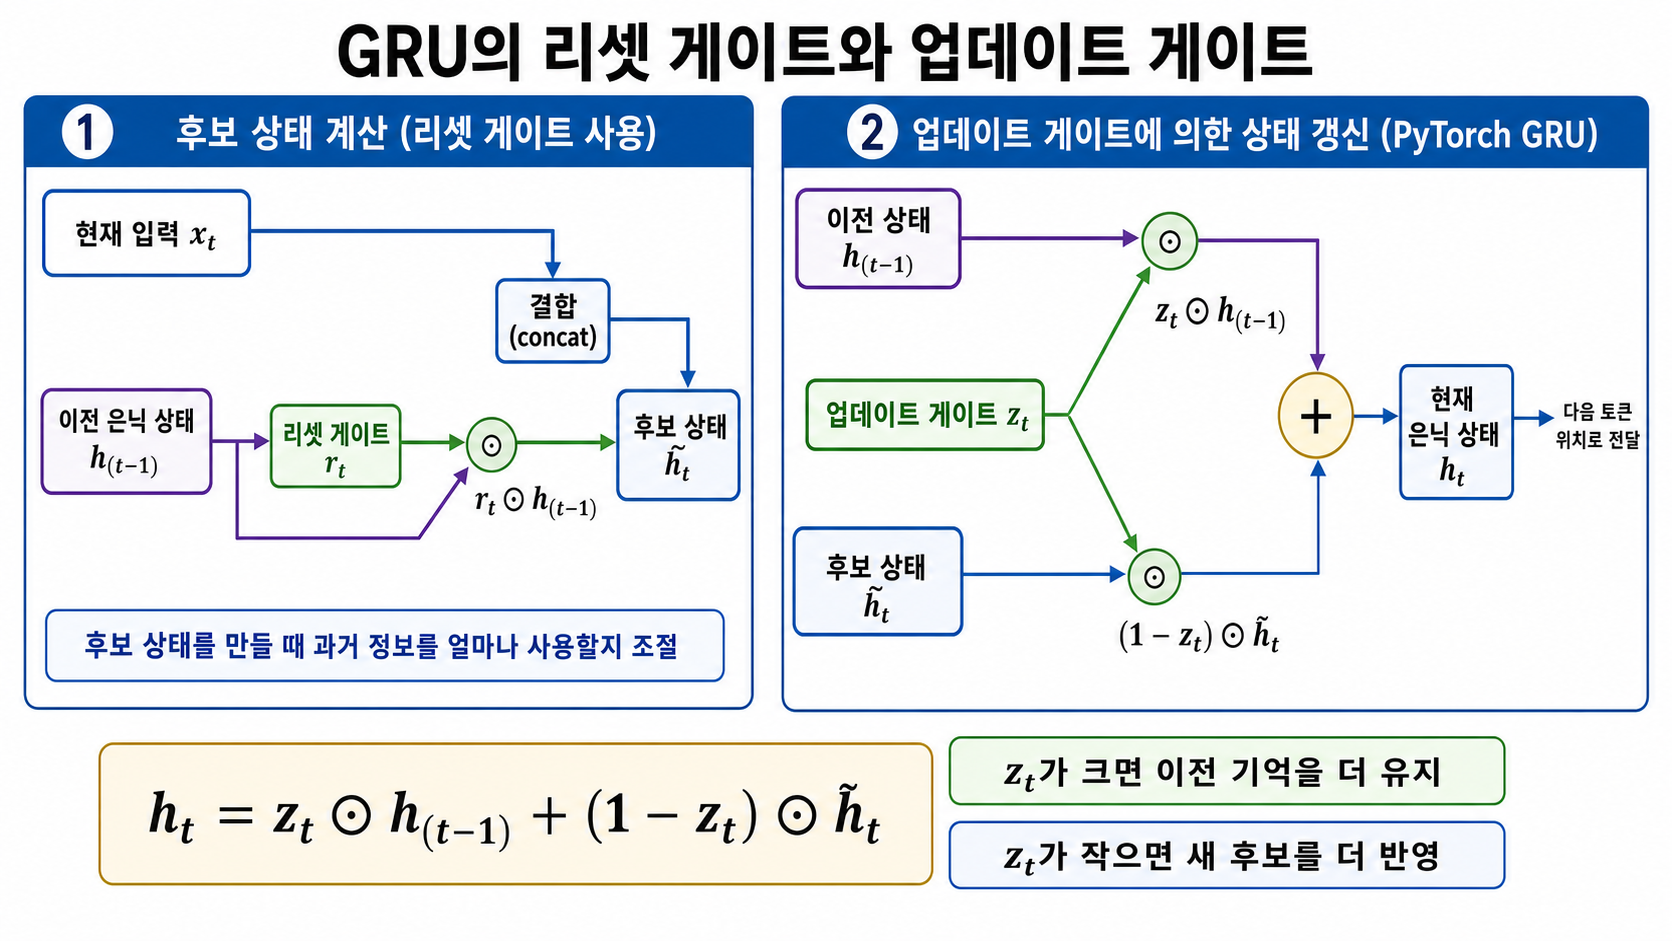

> **그림 읽기:** 이 그림은 두 게이트의 역할을 쉽게 보여 주는 개념도이다. 그림의 후보 상태 $\tilde{h}_t$는 다음 수식의 $n_t$와 같은 의미이며, 리셋 게이트가 곱해지는 정확한 위치는 다음 PyTorch 수식과 직접 계산 코드를 기준으로 확인한다.

### PyTorch GRU의 한 타임 스텝 계산

PyTorch의 `nn.GRU`는 다음 순서로 리셋 게이트, 업데이트 게이트, 후보 상태와 현재 은닉 상태를 계산한다.

```text
r_t = sigmoid(W_ir x_t + b_ir + W_hr h_(t-1) + b_hr)
z_t = sigmoid(W_iz x_t + b_iz + W_hz h_(t-1) + b_hz)
n_t = tanh(W_in x_t + b_in + r_t ⊙ (W_hn h_(t-1) + b_hn))
h_t = z_t ⊙ h_(t-1) + (1 - z_t) ⊙ n_t
```

`sigmoid`는 게이트 값을 `0~1` 범위로 만들고, `tanh`는 후보 상태를 `-1~1` 범위로 만든다. `⊙`는 같은 위치의 값끼리 곱하는 하다마르 곱이다. 그림은 리셋 게이트가 과거 정보의 영향을 줄인다는 개념을 보여 주며, 정확한 PyTorch 식에서는 변환된 이전 상태 `W_hn h_(t-1) + b_hn`에 리셋 게이트를 곱한다.

PyTorch 식에서는 업데이트 게이트 $z_t$가 `1`에 가까울수록 이전 상태를 많이 유지하고, `0`에 가까울수록 새 후보를 많이 반영한다. 상태 벡터의 한 위치만 단순화하면 다음처럼 읽을 수 있다.

```text
이전 상태       : h_(t-1) = 0.80
후보 상태       : n_t = -0.40
업데이트 게이트 : z_t = 0.75

현재 상태 h_t
= 0.75 × 0.80 + (1 - 0.75) × (-0.40)
= 0.60 - 0.10
= 0.50
```

실제 게이트와 상태는 여러 값을 가진 벡터이며, 각 위치에서 서로 다른 유지 비율을 사용할 수 있다. 교재에 따라 $z_t$와 `(1-z_t)`의 역할을 반대로 표기하기도 있으므로 이 노트북에서는 PyTorch 구현의 식을 기준으로 해석한다.

### 문장 속 토큰을 처리하는 방식

다음 두 문장은 토큰 수가 같고 마지막 감성 표현이 다르다.

```text
문장 0: 정말 → 재미 → 있다
문장 1: 전혀 → 재미 → 없다
```

GRU는 두 문장을 한 배치로 입력받더라도 문장별 은닉 상태를 따로 유지한다. 각 문장은 첫 토큰부터 마지막 토큰까지 순서대로 처리되며, 다음 토큰을 처리할 때 같은 문장에서 만들어진 이전 은닉 상태만 사용한다.

학습된 모델은 `전혀`에서 얻은 정보를 이후 `재미`, `없다`를 처리할 때 유지할 수 있다. 업데이트 게이트가 이전 정보를 얼마나 남길지 정하고, 리셋 게이트가 새 후보를 만들 때 과거 문맥을 얼마나 참고할지 조절한다. 다만 게이트에 긍정·부정 규칙이 미리 들어 있는 것은 아니며 학습을 통해 필요한 상태 갱신 방식을 찾는다.

## 03. PyTorch GRU의 입력과 반환값

`batch_first=True`인 `nn.GRU`는 `(배치 크기, 시퀀스 길이, 입력 특성 수)` 형식의 입력을 받는다. 다음 코드의 `(2, 4, 3)`은 시퀀스 2개, 각 시퀀스의 위치 4개, 위치마다 입력 특성 3개를 뜻한다.

```text
입력 same_input : (B, L, I) = (2, 4, 3)
GRU output      : (B, L, H) = (2, 4, 5)
GRU hidden      : (층×방향, B, H) = (1, 2, 5)
```

- **`output`**: 네 위치에서 만들어진 은닉 상태 $h_1, h_2, h_3, h_4$를 모두 보관한 텐서
- **`hidden`**: 마지막 위치까지 처리한 뒤 남은 최종 은닉 상태

한 층 단방향 GRU에서는 `output[:, -1, :]`와 `hidden[-1]`이 같은 마지막 상태를 가리킨다. LSTM과 달리 별도의 `cell`을 반환하지 않는다.

코드는 GRU의 반환값을 확인한 뒤 같은 입력을 RNN과 LSTM에도 전달한다. 세 모델의 `output`과 `hidden` shape가 같아도 내부 상태 갱신식은 서로 다르며, 학습 전 벡터의 크기로 모델 우열을 판단할 수 없다.

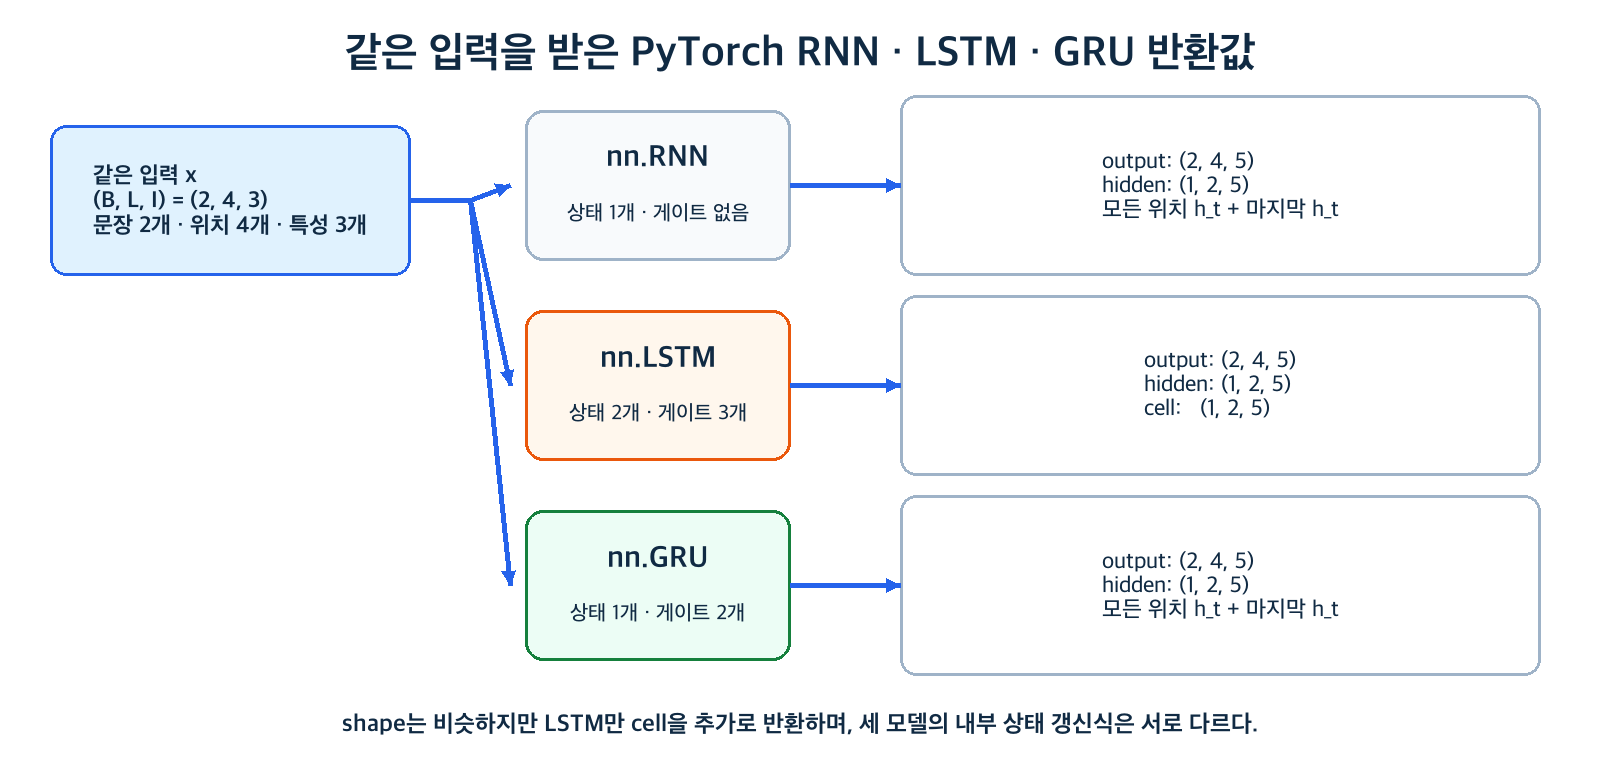

In [1]:
# RNN, LSTM, GRU 반환값 비교

import torch
import torch.nn as nn

torch.manual_seed(42)
torch.set_printoptions(precision=4, sci_mode=False)

batch_size = 2
sequence_length = 4
input_size = 3

hidden_size = 5

same_input = torch.arange(
    batch_size * sequence_length * input_size,
    dtype=torch.float32,
).reshape(
    batch_size,
    sequence_length,
    input_size,
) / 10

rnn = nn.RNN(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)
lstm = nn.LSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)
gru = nn.GRU(
    input_size=input_size,
    hidden_size=hidden_size,
    batch_first=True,
)

rnn_output, rnn_hidden = rnn(same_input)
gru_output, gru_hidden = gru(same_input)

lstm_output, (lstm_hidden, lstm_cell) = lstm(same_input)

print("입력 shape:", same_input.shape)
print("RNN  output / hidden:", rnn_output.shape, rnn_hidden.shape)
print(
    "LSTM output / hidden / cell:",
    lstm_output.shape,
    lstm_hidden.shape,
    lstm_cell.shape,
)
print("GRU  output / hidden:", gru_output.shape, gru_hidden.shape)

print("\n첫 시퀀스의 최종 RNN hidden :", rnn_hidden[0, 0].detach())
print("첫 시퀀스의 최종 LSTM hidden:", lstm_hidden[0, 0].detach())
print("첫 시퀀스의 최종 LSTM cell  :", lstm_cell[0, 0].detach())
print("첫 시퀀스의 최종 GRU hidden :", gru_hidden[0, 0].detach())

print(
    "\n마지막 output과 hidden이 같은가:",
    {
        "RNN": torch.allclose(rnn_output[:, -1], rnn_hidden[-1]),
        "LSTM": torch.allclose(lstm_output[:, -1], lstm_hidden[-1]),
        "GRU": torch.allclose(gru_output[:, -1], gru_hidden[-1]),
    },
)

입력 shape: torch.Size([2, 4, 3])
RNN  output / hidden: torch.Size([2, 4, 5]) torch.Size([1, 2, 5])
LSTM output / hidden / cell: torch.Size([2, 4, 5]) torch.Size([1, 2, 5]) torch.Size([1, 2, 5])
GRU  output / hidden: torch.Size([2, 4, 5]) torch.Size([1, 2, 5])

첫 시퀀스의 최종 RNN hidden : tensor([0.4831, 0.3590, 0.3516, 0.7194, 0.6510])
첫 시퀀스의 최종 LSTM hidden: tensor([-0.1015,  0.0257, -0.2313, -0.0307, -0.1101])
첫 시퀀스의 최종 LSTM cell  : tensor([-0.2043,  0.0879, -0.5042, -0.1345, -0.4400])
첫 시퀀스의 최종 GRU hidden : tensor([-0.2891, -0.6495,  0.3029,  0.1820, -0.5534])

마지막 output과 hidden이 같은가: {'RNN': True, 'LSTM': True, 'GRU': True}


### 실제 출력값을 해석하는 기준

RNN·LSTM·GRU의 `hidden`은 모두 5차원이므로 같은 크기의 분류 계층에 전달할 수 있다. 그러나 기본 RNN은 게이트 없이 상태를 갱신하고, LSTM은 셀 상태를 거쳐 은닉 상태를 만들며, GRU는 업데이트 게이트로 이전 상태와 후보를 섞으므로 실제 숫자는 서로 다르게 나온다.

이 코드에는 정답 레이블, 손실함수와 optimizer가 없다. 따라서 벡터의 부호나 크기를 긍정·부정 확률, 기억한 정보의 양 또는 모델 성능으로 해석할 수 없다. 여기서 확인할 사실은 **같은 입력이라도 내부 구조가 다르면 서로 다른 상태 표현이 만들어진다**는 점이다.

## 04. GRU 한 타임 스텝 직접 계산

`nn.GRU`는 입력 가중치 `weight_ih_l0`과 순환 가중치 `weight_hh_l0`에 리셋 게이트 `r`, 업데이트 게이트 `z`, 후보 상태 `n`의 가중치를 이어 붙여 저장한다. `hidden_size=5`이면 각 계산에 행 5개가 필요하므로 첫 번째 축의 크기는 `3 × 5 = 15`이다.

다음 코드는 첫 번째 입력 위치만 선택하여 PyTorch 저장 순서 `(r, z, n)`로 가중치 계산 결과를 나눈다. 리셋·업데이트 게이트를 만든 뒤 후보 상태와 현재 은닉 상태 $h_1$을 직접 계산한다.

직접 만든 `manual_hidden`이 `gru_output[:, 0, :]`과 같으면 앞의 PyTorch 수식과 실제 `nn.GRU`의 첫 위치 계산이 일치한 것이다. 이 셀은 GRU 내부 원리를 연결하는 직접 구현이므로 뒤의 모델 비교와 별도로 읽는다.

In [2]:
first_input = same_input[:, 0, :]

previous_hidden = torch.zeros(batch_size, hidden_size)

input_linear = (
    first_input @ gru.weight_ih_l0.T
    + gru.bias_ih_l0
)
hidden_linear = (
    previous_hidden @ gru.weight_hh_l0.T
    + gru.bias_hh_l0
)

input_reset, input_update, input_candidate = input_linear.chunk(
    3,
    dim=1,
)
hidden_reset, hidden_update, hidden_candidate = hidden_linear.chunk(
    3,
    dim=1,
)

reset_gate = torch.sigmoid(
    input_reset + hidden_reset
)
update_gate = torch.sigmoid(
    input_update + hidden_update
)

candidate = torch.tanh(
    input_candidate
    + reset_gate * hidden_candidate
)

manual_hidden = (
    update_gate * previous_hidden
    + (1 - update_gate) * candidate
)

print("입력 선형결과 shape:", input_linear.shape)
print("은닉 선형결과 shape:", hidden_linear.shape)
print(
    "reset / update / candidate shape:",
    reset_gate.shape,
    update_gate.shape,
    candidate.shape,
)
print(
    "직접 계산한 h1과 GRU output의 첫 위치가 같은가:",
    torch.allclose(
        manual_hidden,
        gru_output[:, 0, :],
        atol=1e-6,
    ),
)

입력 선형결과 shape: torch.Size([2, 15])
은닉 선형결과 shape: torch.Size([2, 15])
reset / update / candidate shape: torch.Size([2, 5]) torch.Size([2, 5]) torch.Size([2, 5])
직접 계산한 h1과 GRU output의 첫 위치가 같은가: True


## 05. RNN·LSTM·GRU의 구조와 파라미터 비교

순환 계층은 현재 입력에 적용하는 입력 가중치, 이전 은닉 상태에 적용하는 순환 가중치와 편향을 학습한다. 기본 RNN은 후보 은닉 상태 한 묶음, GRU는 리셋·업데이트·후보 상태 세 묶음, LSTM은 입력·망각·출력·후보 셀 네 묶음을 사용한다.

같은 `input_size=3`, `hidden_size=5`에서 파라미터 수를 세면 내부 계산 묶음의 차이가 실제 모델 크기에 어떻게 반영되는지 확인할 수 있다. 현재 PyTorch 계층에서는 RNN 50개, GRU 150개, LSTM 200개가 되므로 GRU는 LSTM 파라미터 수의 `0.75`배이다.

파라미터가 적으면 일반적으로 저장 공간과 한 단계 계산량을 줄일 수 있다. 하지만 실제 학습 속도와 정확도는 데이터, 장치와 구현에 따라 달라지므로 validation 결과를 측정해야 한다.

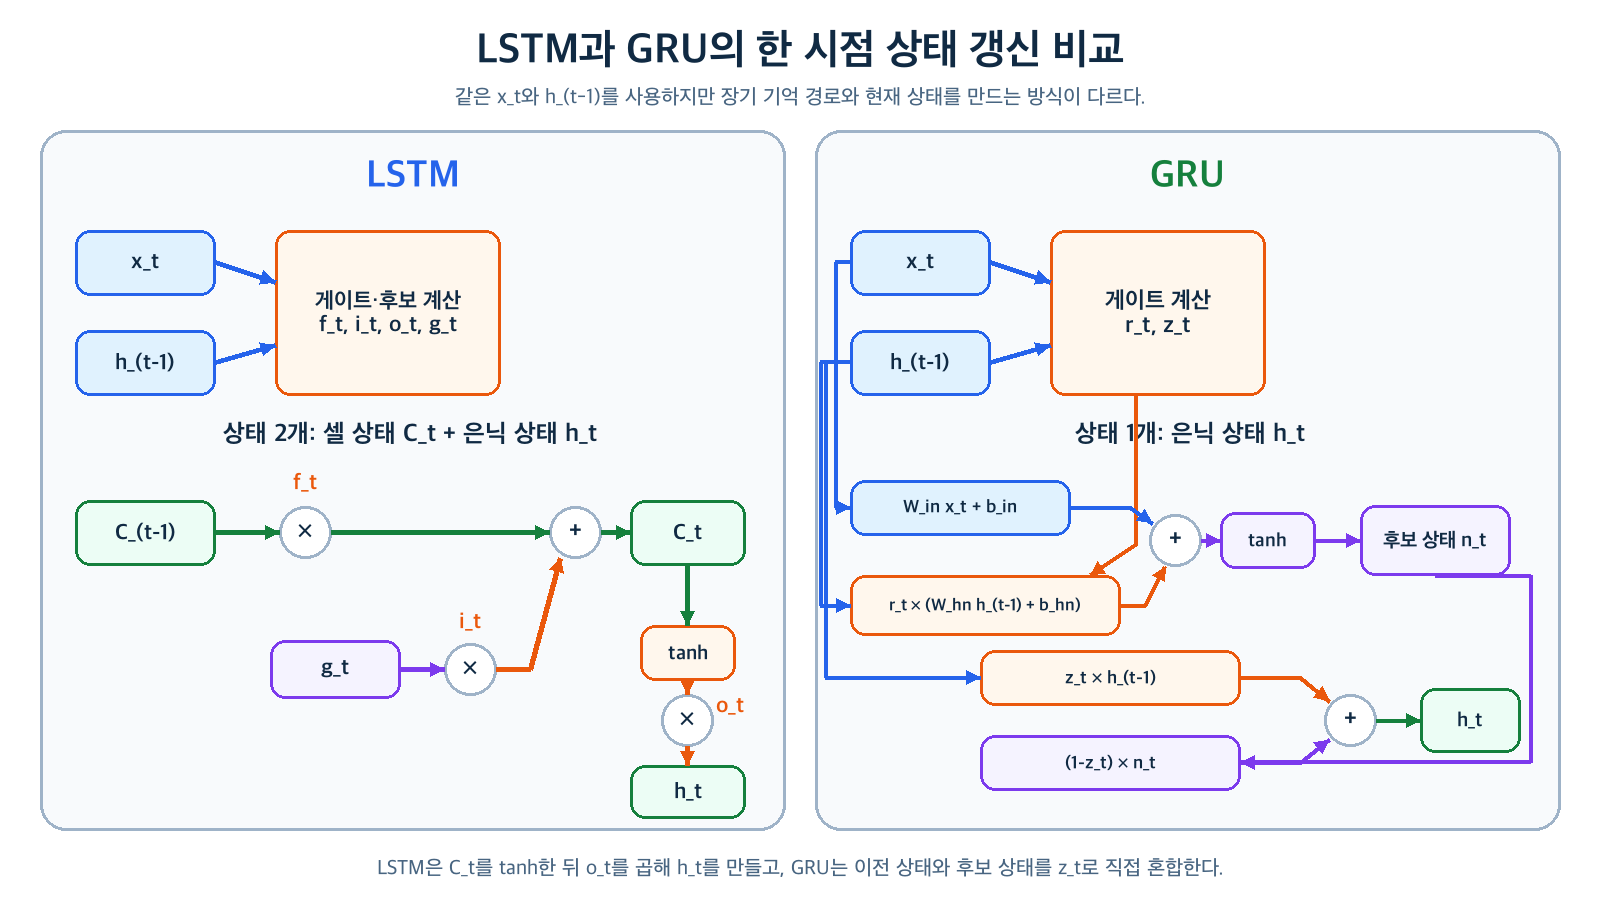

> **그림 읽기:** 이 그림은 LSTM과 GRU의 상태 수와 게이트 수를 비교하는 구조 개요이다. 게이트의 정확한 연결과 계산 순서는 앞의 PyTorch 수식과 직접 계산 코드를 기준으로 해석한다.

In [4]:
def count_trainable_parameters(model):

    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

parameter_counts = {
    "RNN": count_trainable_parameters(rnn),
    "GRU": count_trainable_parameters(gru),
    "LSTM": count_trainable_parameters(lstm),
}

for model_name, parameter_count in parameter_counts.items():
    print(f"{model_name:4} 파라미터 수: {parameter_count}")

print(
    "GRU / LSTM 비율:",
    f"{parameter_counts['GRU'] / parameter_counts['LSTM']:.2f}",
)

RNN  파라미터 수: 50
GRU  파라미터 수: 150
LSTM 파라미터 수: 200
GRU / LSTM 비율: 0.75


## 06. 같은 문장을 처리할 때 생기는 표현 차이

RNN·LSTM·GRU는 모두 토큰을 앞에서 뒤로 읽고 마지막 은닉 상태를 문장 벡터로 사용할 수 있다. 차이는 토큰의 처리 순서가 아니라 앞에서 읽은 정보를 다음 위치에 남기는 방법이다.

다음 코드는 `정말 → 재미 → 있다`와 `전혀 → 재미 → 없다`를 설명용 3차원 입력으로 바꾼다. 각 위치의 세 값은 `[긍정 단서, 부정 단서, 강조 단서]`를 나타내며 학습된 단어 임베딩과는 다르다.

세 모델에 완전히 같은 입력을 전달하고 마지막 은닉 상태를 같은 `nn.Linear` 계층에 넣는다. 내부 상태 갱신 방식이 다르므로 문장 벡터와 로짓도 다르게 나오지만, 순환 계층과 분류 계층 모두 학습 전이므로 실제 감성 예측이나 성능 차이로 해석할 수 없다.

In [5]:
sentence_input = torch.tensor(
    [
        [
            [0.0, 0.0, 1.0],
            [0.2, 0.2, 0.0],
            [1.0, 0.0, 0.0],
        ],
        [
            [0.0, 0.0, 1.0],
            [0.2, 0.2, 0.0],
            [0.0, 1.0, 0.0],
        ],
    ],
    dtype=torch.float32,
)

rnn_sentence_output, rnn_sentence_hidden = rnn(sentence_input)
lstm_sentence_output, (
    lstm_sentence_hidden,
    lstm_sentence_cell,
) = lstm(sentence_input)
gru_sentence_output, gru_sentence_hidden = gru(sentence_input)

sentence_vectors = {
    "RNN": rnn_sentence_hidden[-1],
    "LSTM": lstm_sentence_hidden[-1],
    "GRU": gru_sentence_hidden[-1],
}

shared_classifier = nn.Linear(hidden_size, 1)

with torch.no_grad():
    for model_name, sentence_vector in sentence_vectors.items():

        logits = shared_classifier(sentence_vector).squeeze(1)

        print(f"\n[{model_name}]")
        print("첫 문장 벡터:", sentence_vector[0].detach())
        print("둘째 문장 벡터:", sentence_vector[1].detach())
        print("학습 전 로짓:", logits)


[RNN]
첫 문장 벡터: tensor([ 0.2397,  0.5374, -0.0936,  0.2748,  0.3602])
둘째 문장 벡터: tensor([0.2671, 0.0915, 0.3684, 0.7611, 0.1069])
학습 전 로짓: tensor([-0.3101, -0.3941])

[LSTM]
첫 문장 벡터: tensor([-0.0744, -0.0194, -0.0668, -0.0620, -0.1263])
둘째 문장 벡터: tensor([-0.1347,  0.1002, -0.2024, -0.0633, -0.1018])
학습 전 로짓: tensor([-0.3913, -0.3551])

[GRU]
첫 문장 벡터: tensor([-0.0772, -0.4960, -0.1006,  0.2558, -0.3443])
둘째 문장 벡터: tensor([-0.1701, -0.4950,  0.2487,  0.2817, -0.3240])
학습 전 로짓: tensor([-0.5057, -0.4830])


## 07. 토큰 ID에서 GRU 분류 로짓까지

실제 텍스트 분류에서는 단어를 사람이 만든 세 개의 특성값으로 표현하지 않는다. 토큰 ID를 `nn.Embedding`으로 밀집 벡터로 바꾸고, GRU가 유효한 토큰을 순서대로 처리하여 최종 은닉 상태를 만든다. 이 최종 상태가 문장 벡터이며 `nn.Linear`가 문장별 분류 로짓으로 변환한다.

길이가 다른 문장을 한 배치로 만들면 오른쪽에 PAD를 추가한다. `pack_padded_sequence()`에 PAD를 제외한 실제 길이를 전달하면 GRU가 PAD 위치를 상태 갱신에서 제외한다.

```text
토큰 ID (B, L)
    → Embedding (B, L, E)
    → GRU hidden (1, B, H)
    → 문장 벡터 (B, H)
    → Linear 로짓 (B,)
```

다음 예제의 두 문장은 저장 길이가 3으로 같지만 실제 길이는 `[3, 2]`이다. 출력 로짓은 아직 학습하지 않은 값이므로 shape 흐름만 확인한다. 뒤의 NSMC 교안에서 `BCEWithLogitsLoss`, 역전파와 optimizer를 연결한 뒤 감성 분류에 사용한다.

In [6]:
from torch.nn.utils.rnn import pack_padded_sequence

class GRUSentenceClassifier(nn.Module):
    def __init__(
        self,
        vocabulary_size,
        embedding_dim,
        hidden_size,
    ):
        # nn.Module을 초기화해야 아래 계층의 가중치가 모델 파라미터로 등록된다.
        super().__init__()

        # 토큰 ID는 임베딩 가중치의 행 번호로 사용되어 E차원 토큰 벡터로 변환된다.
        # padding_idx=0은 PAD 행을 0 벡터로 유지하고 학습으로 갱신하지 않는 설정이다.
        self.embedding = nn.Embedding(
            num_embeddings=vocabulary_size,
            embedding_dim=embedding_dim,
            padding_idx=0,
        )

        # GRU의 input_size는 임베딩이 출력하는 마지막 축 E와 같아야 한다.
        # 한 층 단방향 GRU는 최종 hidden을 `(1, B, H)`로 반환한다.
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            batch_first=True,
        )

        # Linear는 각 문장의 H차원 벡터를 시그모이드 적용 전 이진 로짓 하나로 바꾼다.
        self.classifier = nn.Linear(
            hidden_size,
            1,
        )


    def forward(self, token_ids, lengths):
        # 정수 ID `(B, L)`의 각 값을 같은 번호의 임베딩 행으로 바꾸어 `(B, L, E)`를 만든다.
        embedded = self.embedding(token_ids)

        # lengths는 각 문장에서 PAD를 제외한 실제 토큰 수이다.
        # enforce_sorted=False이면 배치를 길이순으로 미리 정렬하지 않아도 된다.
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        # 위치별 packed output은 사용하지 않고 마지막 유효 토큰 뒤의 hidden만 받는다.
        # GRU는 LSTM과 달리 별도의 cell을 반환하지 않는다.
        _, hidden = self.gru(packed)

        # 한 층 단방향이므로 hidden[-1]은 `(B, H)` 문장 벡터이다.
        sentence_vector = hidden[-1]

        # `(B, H)`를 `(B, 1)`로 바꾸고 크기 1인 클래스 축만 제거하여 `(B,)` 로짓을 반환한다.
        logits = self.classifier(sentence_vector).squeeze(1)
        return logits, embedded, hidden, sentence_vector


# 어휘 사전에서 PAD는 0이고 실제 단어는 1부터 시작한다.
token_to_id = {
    "<PAD>": 0,
    "정말": 1,
    "재미": 2,
    "있다": 3,
    "없다": 4,
}

# 첫 문장은 토큰 3개, 둘째 문장은 토큰 2개 뒤에 PAD 0을 붙여 저장 길이를 3으로 맞춘다.
token_ids = torch.tensor(
    [
        [1, 2, 3],
        [2, 4, 0],
    ],
    dtype=torch.long,
)
lengths = torch.tensor([3, 2])

# V=5는 ID 0~4, E=4는 토큰 벡터 크기, H=5는 GRU 문장 벡터 크기를 뜻한다.
torch.manual_seed(7)
gru_classifier = GRUSentenceClassifier(
    vocabulary_size=len(token_to_id),
    embedding_dim=4,
    hidden_size=5,
)

# 아직 학습하지 않은 모델을 한 번 실행하여 입력부터 로짓까지 shape만 추적한다.
logits, embedded, hidden, sentence_vector = gru_classifier(
    token_ids,
    lengths,
)

print("토큰 ID shape:", token_ids.shape)
print("실제 길이:", lengths.tolist())
print("임베딩 shape:", embedded.shape)
print("GRU hidden shape:", hidden.shape)
print("문장 벡터 shape:", sentence_vector.shape)
print("분류 로짓 shape:", logits.shape)
print("학습 전 로짓:", logits.detach())

토큰 ID shape: torch.Size([2, 3])
실제 길이: [3, 2]
임베딩 shape: torch.Size([2, 3, 4])
GRU hidden shape: torch.Size([1, 2, 5])
문장 벡터 shape: torch.Size([2, 5])
분류 로짓 shape: torch.Size([2])
학습 전 로짓: tensor([-0.0388, -0.0189])


## 08. GRU 핵심 정리와 모델 선택
(* GRU 기억할 특징: 게이트 2개, LSTM보다 파라미터 적음, cell 없이도 장기기억O )

GRU는 업데이트 게이트와 리셋 게이트를 사용해 은닉 상태 하나를 갱신한다. LSTM의 별도 셀 상태와 출력 게이트를 제거하여 구조를 단순화했지만, 이전 정보를 선택적으로 유지하고 새 후보를 반영하는 게이트의 목적은 유지한다.

- **리셋 게이트 $r_t$**: 새 후보 상태를 만들 때 이전 정보의 영향을 조절
- **업데이트 게이트 $z_t$**: 이전 상태와 새 후보 상태의 혼합 비율을 조절
- **후보 상태 $n_t$**: 현재 입력과 조절된 이전 정보로 만든 새로운 기억 후보
- **PyTorch 반환값**: `output, hidden`
- **문장 분류 사용처**: 마지막 `hidden`을 `Linear`에 전달해 문장별 로짓 생성

기본 RNN은 빠른 기준선을 만들 때 유용하고, LSTM은 별도의 셀 상태를 통한 장기 기억 경로가 필요할 때 비교할 수 있다. GRU는 LSTM과 비슷한 게이트 효과를 더 적은 파라미터로 시도할 때 유용하다. 최종 모델은 이름이나 학습 전 출력이 아니라 같은 데이터 분할과 학습 조건에서 validation 손실·정확도·F1·학습 시간을 비교하여 선택한다.